<a href="https://colab.research.google.com/github/ppranshu11/E-commerce-Company-Analysis-/blob/main/E_commerce_Company_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/sales_dataset.csv")
print(data)

<ipython-input-4-eefa2c51a08c>:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/sales_dataset.csv")


                   Order ID      Date                        Status  \
0       405-8078784-5731545  04-30-22                     Cancelled   
1       171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2       404-0687676-7273146  04-30-22                       Shipped   
3       403-9615377-8133951  04-30-22                     Cancelled   
4       407-1069790-7240320  04-30-22                       Shipped   
...                     ...       ...                           ...   
128944  406-6001380-7673107  05-31-22                       Shipped   
128945  402-9551604-7544318  05-31-22                     Cancelled   
128946  407-9547469-3152358  05-31-22                       Shipped   
128947  402-6184140-0545956  05-31-22                       Shipped   
128948  408-7436540-8728312  05-31-22                       Shipped   

       Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0        Merchant      Amazon.in           Standard   SET389   SET

In [ ]:
#Display First five row for understand the data
data.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# Remove Duplicate
data = data.drop_duplicates()

In [ ]:
# Find Null Values
print(data.isnull().sum())
# in amount having 7791 data is Null

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6871
Qty                       0
currency               7791
Amount                 7791
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49139
B2B                       0
fulfilled-by          89673
Unnamed: 22           49039
dtype: int64


In [ ]:
df= pd.DataFrame(data)
print(df)

                   Order ID      Date                        Status  \
0       405-8078784-5731545  04-30-22                     Cancelled   
1       171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2       404-0687676-7273146  04-30-22                       Shipped   
3       403-9615377-8133951  04-30-22                     Cancelled   
4       407-1069790-7240320  04-30-22                       Shipped   
...                     ...       ...                           ...   
128944  406-6001380-7673107  05-31-22                       Shipped   
128945  402-9551604-7544318  05-31-22                     Cancelled   
128946  407-9547469-3152358  05-31-22                       Shipped   
128947  402-6184140-0545956  05-31-22                       Shipped   
128948  408-7436540-8728312  05-31-22                       Shipped   

       Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0        Merchant      Amazon.in           Standard   SET389   SET

In [ ]:
# Check unique order statuses
df['Status'].unique()

array(['Cancelled', 'Shipped - Delivered to Buyer', 'Shipped',
       'Shipped - Returned to Seller', 'Shipped - Rejected by Buyer',
       'Shipped - Lost in Transit', 'Shipped - Out for Delivery',
       'Shipped - Returning to Seller', 'Shipped - Picked Up', 'Pending',
       'Pending - Waiting for Pick Up', 'Shipped - Damaged', 'Shipping'],
      dtype=object)

In [ ]:
# Identify and replace null values in 'Amount' column for 'Cancelled' status with 0
df.loc[df['Status'] == 'Cancelled', 'Amount'] = 0


In [ ]:
# Verify that the replacement worked
print(df[df['Status'] == 'Cancelled'])
print(df[df['Status'] == 'Shipped - Returned to Seller'])
print(df[df['Status'] == 'Shipped - Returning to Seller'])
print(df[df['Status'] == 'Shipped - Rejected by Buyer'])

                   Order ID      Date     Status Fulfilment Sales Channel   \
0       405-8078784-5731545  04-30-22  Cancelled   Merchant      Amazon.in   
3       403-9615377-8133951  04-30-22  Cancelled   Merchant      Amazon.in   
8       407-5443024-5233168  04-30-22  Cancelled     Amazon      Amazon.in   
11      171-4638481-6326716  04-30-22  Cancelled     Amazon      Amazon.in   
17      404-6019946-2909948  04-30-22  Cancelled   Merchant      Amazon.in   
...                     ...       ...        ...        ...            ...   
128938  404-2225394-8024308  05-31-22  Cancelled     Amazon      Amazon.in   
128939  408-5154281-4593912  05-31-22  Cancelled     Amazon      Amazon.in   
128941  404-5182288-1653947  05-31-22  Cancelled     Amazon      Amazon.in   
128943  404-3802633-7250760  05-31-22  Cancelled     Amazon      Amazon.in   
128945  402-9551604-7544318  05-31-22  Cancelled     Amazon      Amazon.in   

       ship-service-level    Style                  SKU       C

In [ ]:
# to check the entire data to confirm the change
print(df.head())

              Order ID      Date                        Status Fulfilment  \
0  405-8078784-5731545  04-30-22                     Cancelled   Merchant   
1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   Merchant   
2  404-0687676-7273146  04-30-22                       Shipped     Amazon   
3  403-9615377-8133951  04-30-22                     Cancelled   Merchant   
4  407-1069790-7240320  04-30-22                       Shipped     Amazon   

  Sales Channel  ship-service-level    Style              SKU       Category  \
0      Amazon.in           Standard   SET389   SET389-KR-NP-S            Set   
1      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL          kurta   
2      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL          kurta   
3      Amazon.in           Standard    J0341       J0341-DR-L  Western Dress   
4      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL            Top   

  Size  ... currency Amount    ship-city   ship-state  s

In [ ]:
# Group by 'Status' and calculate the total amount and print
status_amount = df.groupby('Status')['Amount'].sum()
print("Total Amount by Order Status:")
print(status_amount)

Total Amount by Order Status:
Status
Cancelled                               0.00
Pending                            430271.00
Pending - Waiting for Pick Up      192138.00
Shipped                          50295761.57
Shipped - Damaged                    1136.00
Shipped - Delivered to Buyer     18652333.05
Shipped - Lost in Transit            1997.00
Shipped - Out for Delivery          26971.00
Shipped - Picked Up                661252.00
Shipped - Rejected by Buyer          7295.00
Shipped - Returned to Seller      1269644.00
Shipped - Returning to Seller      107620.00
Shipping                                0.00
Name: Amount, dtype: float64


In [ ]:
# Check for null values in the 'Amount' column
null_values = df['Amount'].isnull().sum()

# Print the number of null values in 'Amount'
print(f"Number of null values in 'Amount': {null_values}")

# If you want to see the rows with null values in 'Amount'
null_rows = df[df['Amount'].isnull()]
print("Rows with null values in 'Amount':")
print(null_rows)

Number of null values in 'Amount': 231
Rows with null values in 'Amount':
                   Order ID        Date   Status Fulfilment Sales Channel   \
928     S02-5278980-4327051    04-30-22  Shipped     Amazon     Non-Amazon   
1048    S02-9107114-0460608    04-30-22  Shipped     Amazon     Non-Amazon   
1606    405-7790745-1369118    04-29-22  Shipped     Amazon      Amazon.in   
1980    171-9673855-2321133    04-29-22  Shipped     Amazon      Amazon.in   
2415    404-7478762-7926753    04-29-22  Shipped     Amazon      Amazon.in   
...                     ...         ...      ...        ...            ...   
124599  S02-2059602-9568060  06-04-2022  Shipped     Amazon     Non-Amazon   
124600  S02-3811761-8377519  06-04-2022  Shipped     Amazon     Non-Amazon   
124602  S02-5216693-3162561  06-04-2022  Shipped     Amazon     Non-Amazon   
124604  S02-7324586-1573702  06-04-2022  Shipped     Amazon     Non-Amazon   
128068  406-6890147-5272318  06-01-2022  Shipped     Amazon      Ama

In [ ]:
# Calculate the median amount
df= pd.DataFrame(data)
median_amount = data['Amount'].median()
print(median_amount)

545.0


In [ ]:

# Replace the first NaN value with 0
 # Find the index of the first NaN value
#first_nan_index = df['Amount'].isna().idxmax()
#if pd.notna(first_nan_index):  # Check if there's at least one NaN
    #df.loc[first_nan_index, 'Amount'] = 0

# Now replace remaining NaN values with the median
median_amount = df['Amount'].median()
df['Amount'] = df['Amount'].fillna(median_amount)

# Print the result
print("DataFrame after replacing first NaN value with 0, and remaining NaN values with the median:")
print(df['Amount'])


DataFrame after replacing first NaN value with 0, and remaining NaN values with the median:
0            0.0
1          406.0
2          329.0
3            0.0
4          574.0
           ...  
128944     517.0
128945       0.0
128946     690.0
128947    1199.0
128948     696.0
Name: Amount, Length: 128943, dtype: float64


In [ ]:
count_rows_537 = df[df['Amount'] == 537.0].shape[0]
print(count_rows_537)

186


In [ ]:
# aftr replacing value with median amount not getting  null values
print (df['Amount'].isnull().sum())

0


In [ ]:
print(df.isnull().sum())

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6871
Qty                       0
currency               7791
Amount                    0
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49139
B2B                       0
fulfilled-by          89673
Unnamed: 22           49039
dtype: int64


In [ ]:
df.describe()

,Qty,Amount,ship-postal-code
count,128943.000000,128943.000000,128910.00000
mean,0.904648,556.620473,463978.72546
std,0.314758,346.485412,191471.57590
min,0.000000,0.000000,110001.00000
25%,1.000000,376.000000,382421.00000
50%,1.000000,545.000000,500033.00000
75%,1.000000,760.000000,600024.00000
max,15.000000,5584.000000,989898.00000


In [ ]:
# Calculate the total revenue and find the round figure
TR= df.loc[df['Status'] != 'Cancelled','Amount'].astype(float).sum()
TR_INR = TR / 1_000
print(f"Total Revenue in Thousands: {TR_INR:.0f}K")


Total Revenue in Thousands: 71772K


In [ ]:
# Calculate the average of orders
average_order_value = df.groupby('Order ID')['Amount'].sum().mean()
print("Average Order Value:", average_order_value)

Average Order Value: 596.3533104559958


In [ ]:
# calculate top selling product
top_products = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)
print("Top Selling Products:")
print(top_products.head(10))

Top Selling Products:
Category
Set              45286
kurta            45048
Western Dress    13943
Top               9902
Ethnic Dress      1052
Blouse             864
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64


In [ ]:
#top selling product by quantity and Amount
top_selling_categories = data.groupby('Category')[['Qty', 'Amount']].sum().sort_values(by='Qty', ascending=False).head(10)

print("Top Selling Categories by Quantity and Revenue:\n", top_selling_categories)

Top Selling Categories by Quantity and Revenue:
                  Qty       Amount
Category                         
Set            45286  35720805.14
kurta          45048  19418229.48
Western Dress  13943  10203500.00
Top             9902   4902917.00
Ethnic Dress    1052    731516.00
Blouse           864    418389.00
Bottom           398    135453.00
Saree            152    114694.00
Dupatta            3       915.00


<ipython-input-30-481973035882>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Qty', y='Category', data=category_sales, palette='Blues')


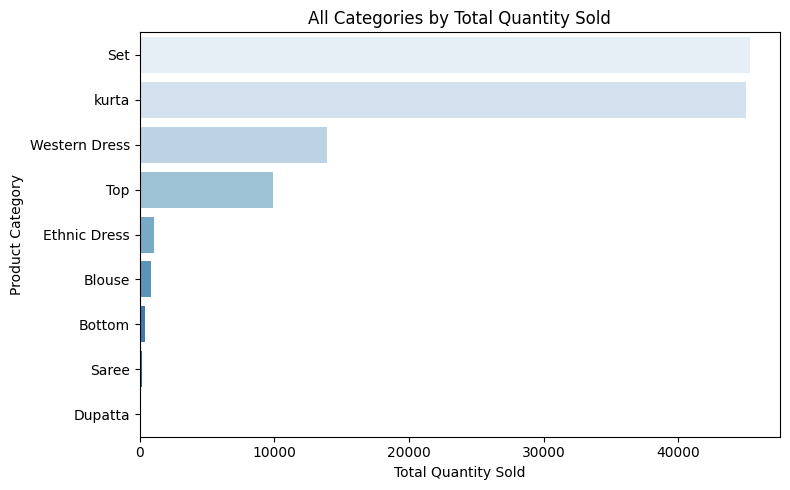

In [ ]:
# find total quantity sold per category
category_sales = df.groupby('Category')['Qty'].sum().reset_index().sort_values(by='Qty', ascending=False)

# Plot the data using Seaborn for a better visualization
plt.figure(figsize=(8, 5))
sns.barplot(x='Qty', y='Category', data=category_sales, palette='Blues')
# Adding labels and title
plt.title('All Categories by Total Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Category')
plt.tight_layout()
# Show the plot
plt.show()

<ipython-input-31-5b3df4d3ec3c>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


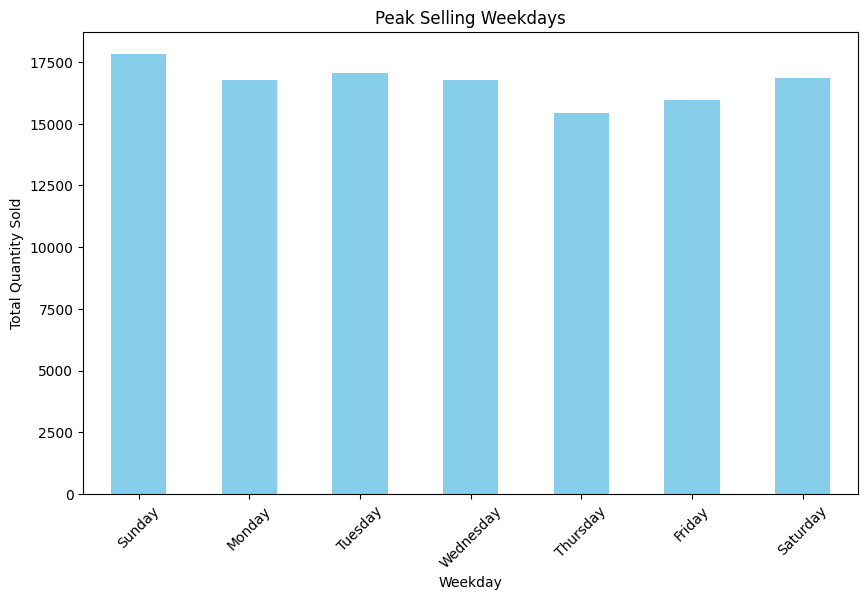

In [ ]:
import calendar
# Peak Selling weekdays
data['Date'] = pd.to_datetime(data['Date'])
weekday_sales = data.groupby(data['Date'].dt.day_name())['Qty'].sum().reindex(['Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
weekday_sales.plot(kind='bar', color='skyblue', figsize=(10, 6), title='Peak Selling Weekdays', xlabel='Weekday', ylabel='Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

<ipython-input-32-fab87d16d488>:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


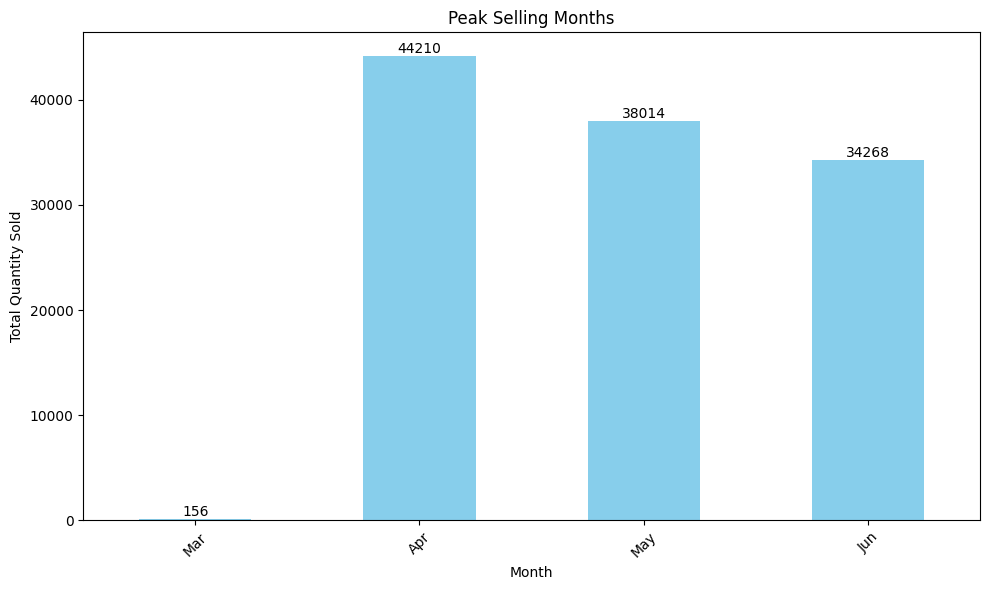

In [ ]:
import calendar
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'Qty' and 'Date' are your relevant columns

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract 'Month' from the 'Date' column
df['Month'] = df['Date'].dt.month

# Group by 'Month' and sum the 'Qty' values for each month
monthly_sales = df.groupby(df['Month'])['Qty'].sum()

# Plot the bar chart for Peak Selling Months
plt.figure(figsize=(10, 6))
ax = monthly_sales.plot(kind='bar', color='skyblue', title='Peak Selling Months', xlabel='Month', ylabel='Total Quantity Sold')

# Get the months that actually exist in the data
existing_months = monthly_sales.index

# Set x-ticks to show only the existing months
plt.xticks(ticks=range(len(existing_months)), labels=[calendar.month_abbr[m] for m in existing_months], rotation=45)

# Add data labels on top of each bar
for i, value in enumerate(monthly_sales):
    ax.text(i, value + 0.5, f'{value}', ha='center', va='bottom', fontsize=10)  # Add labels slightly above the bar

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().nlargest(3)

,Amount
Date,
2022-04,26278569.62
2022-05,23982071.00
2022-06,21416318.00


In [ ]:
# calculating top performing 'City'
top_performing_location = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(5)
top_performing_location

,Amount
ship-city,
BENGALURU,6349713.00
HYDERABAD,4499883.57
MUMBAI,3400494.00
NEW DELHI,3331168.48
CHENNAI,2823610.00


In [ ]:
# calculating top performing 'state'
df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(8)

,Amount
ship-state,
MAHARASHTRA,12233176.00
KARNATAKA,9648329.00
TELANGANA,6293653.57
UTTAR PRADESH,6184515.00
TAMIL NADU,5958817.00
DELHI,3907340.48
KERALA,3378602.00
WEST BENGAL,3208055.00


In [ ]:
import plotly.express as px

# Group by 'ship-state' and sum the sales 'Amount'
state_sales = df.groupby(['ship-state'])['Amount'].sum().reset_index()

# Filter out states where the total sales amount is zero
state_sales = state_sales[state_sales['Amount'] > 0]

# Create a Treemap
fig = px.treemap(state_sales,
                 path=['ship-state'],  # Hierarchical path
                 values='Amount',
                 color='Amount',  # Color by sales amount
                 color_continuous_scale='Viridis',  # Color scale
                 title='Sales by State')

# Show the Treemap
fig.show()


In [ ]:
# Calculate the count of specific values in the 'Calculated Status' column
return_and_cancelled_counts = df['Status'].value_counts()

# Filter the counts for 'Shipped - Return to Seller', 'Cancelled', and 'Shipped - Returning to Seller'
specific_status_counts = return_and_cancelled_counts[
    return_and_cancelled_counts.index.isin(['Shipped - Returned to Seller', 'Cancelled', 'Shipped - Returning to Seller','Shipped - Rejected by Buyer'])
]

# Calculate the total count of the filtered statuses
cancelled_orders = specific_status_counts.sum()

# Display the specific counts and total
specific_status_counts

,count
Status,
Cancelled,18338
Shipped - Returned to Seller,1953
Shipped - Returning to Seller,145
Shipped - Rejected by Buyer,11


In [ ]:
cancelled_orders

20447

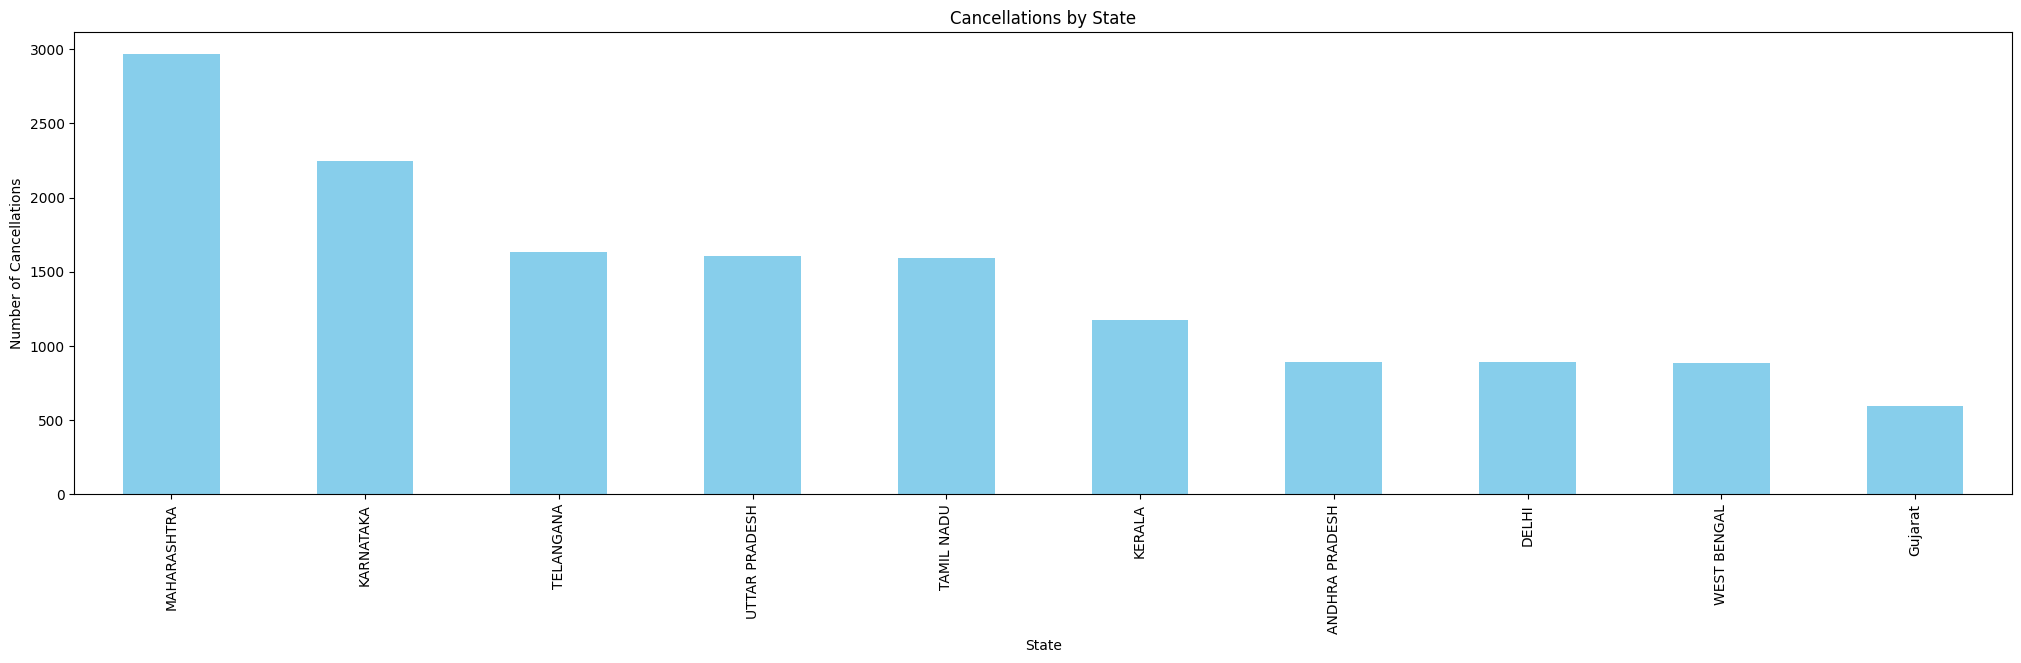

In [ ]:
# Filter for cancelled orders (assuming 'Status' column indicates cancellation)
canceled_orders = data[data['Status'] == 'Cancelled']

# Group by state and count cancellations
state_cancellations = canceled_orders.groupby('ship-state')['Order ID'].count().sort_values(ascending=False).head(10)

# Plot cancellations by state
state_cancellations.plot(kind='bar', color='Skyblue', figsize=(25, 6), title='Cancellations by State')
plt.xlabel('State')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=90)
plt.show()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128943 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128943 non-null  object        
 1   Date                128943 non-null  datetime64[ns]
 2   Status              128943 non-null  object        
 3   Fulfilment          128943 non-null  object        
 4   Sales Channel       128943 non-null  object        
 5   ship-service-level  128943 non-null  object        
 6   Style               128943 non-null  object        
 7   SKU                 128943 non-null  object        
 8   Category            128943 non-null  object        
 9   Size                128943 non-null  object        
 10  ASIN                128943 non-null  object        
 11  Courier Status      122072 non-null  object        
 12  Qty                 128943 non-null  int64         
 13  currency            121152 non-nul

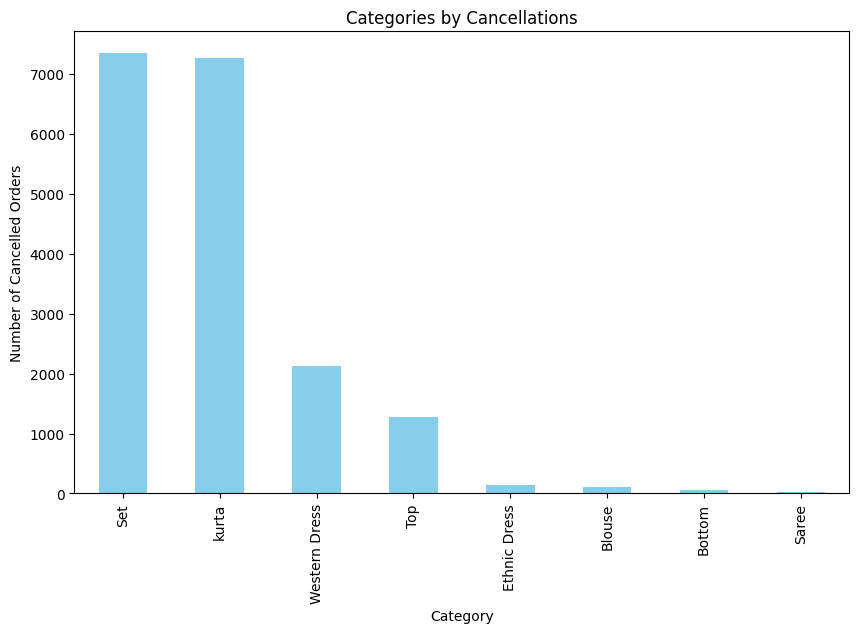

In [ ]:

category_cancellations = data[data['Status'] == 'Cancelled'].groupby('Category')['Order ID'].count().sort_values(ascending=False).head(10)

# Categories by Cancellations
plt.figure(figsize=(10, 6))
category_cancellations.plot(kind='bar', color='skyblue')
plt.title('Categories by Cancellations')
plt.ylabel('Number of Cancelled Orders')
plt.show()

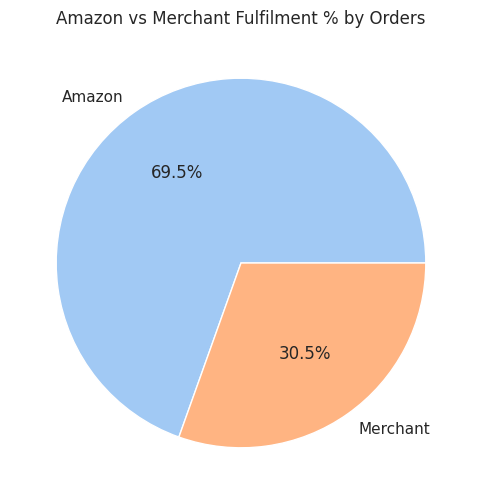

In [ ]:
# Amazon Vs merchant  % pie chart  by order

# Fulfilment analysis
fulfilment_percentages = data['Fulfilment'].value_counts(normalize=True) * 100

# Plot pie chart
plt.figure(figsize=(6, 6))
sns.set_theme(style="whitegrid")
fulfilment_percentages.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel"),
    title="Amazon vs Merchant Fulfilment % by Orders"
)
plt.ylabel('')  # Remove y-axis label
plt.show()

In [ ]:
#Differentiating B2B vs B2C
b2b_orders = data[data['B2B'] == True].shape[0]
b2c_orders = data[data['B2B'] == False].shape[0]
b2b_orders,b2c_orders



(871, 128072)

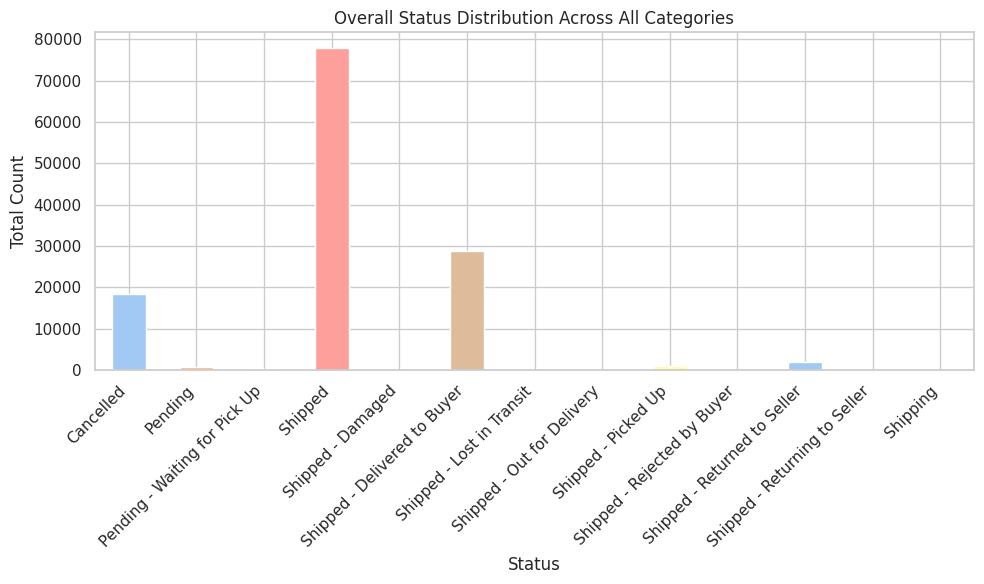

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# df is the original DataFrame containing 'Category' and 'Status' columns

# Step 1: Calculate status counts by category
status_by_category = df.groupby(['Category', 'Status']).size().unstack(fill_value=0)

# Step 2: Sum counts across categories for each status (Total Sum)
status_total = status_by_category.sum(axis=0)

# Step 3: Plot a bar chart for the total status distribution (without percentages)
plt.figure(figsize=(10, 6))  # Set figure size for better readability

# Plot the total sum of occurrences for each status
status_total.plot(
    kind='bar',
    color=sns.color_palette("pastel"),
    title='Overall Status Distribution Across All Categories'
)

# Step 4: Add axis labels for clarity
plt.xlabel('Status')  # X-axis label
plt.ylabel('Total Count')  # Y-axis label
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.tight_layout()  # Ensure the layout looks good
plt.show()


In [ ]:
##sales_dataset.csv
# Replace 'df' with the variable name of your cleaned DataFrame
df.to_csv('cleaned_dataset.csv', index=False)
from google.colab import files
files.download('cleaned_dataset.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sum= df['Amount'].sum()
print(sum)

71772313.62


# **Insights**

Total Revenue and Average Order Value:

The total revenue is about 71,772 INR.
On average, each order is worth around 596.3 INR.





Top Selling Products and Categories:

The "Set" category sells the most, followed by "kurta," "Western Dress," and "Top".
The "Set" category also makes the highest revenue, followed by "kurta" and "Western Dress".




Quantity and Revenue Analysis:

More sales in categories like "Set" and "kurta" lead to higher revenue.
Other categories, like "Ethnic Dress," "Blouse," "Bottom," and "Saree," have lower sales and revenue, which could mean they are less popular or for niche buyers.


Handling Missing Data:

Missing values in the "Amount" and "currency" columns were filled with the median value. This kept the data accurate without affecting the results.
